In [49]:
import numpy as np
from matplotlib import pyplot as plt

In [50]:
# Define global parameters
lmd = 500.0e-9
k = 2*np.pi/lmd

### Aperture class

In [51]:
class aperture:
    """
    General aperture class from which specific apertures like single slit, sinusoidal gratings etc. 
    inherit. Includes methods to plot the aperture and find the near/far field diffraction intensities
    """
    def __init__(self, L, N):
        # Initialise basic parameters of aperture
        self.L = L # Extent of sampling window
        self.N = N # Number of sample points

        # Define sample window
        self.x = np.linspace(-L/2, L/2, N)

        # Initialise aperture function
        self.A = np.zeros_like(self.x, dtype='complex')


    def plot(aperture, xrange=0):
        """Method to plot the (real part of the) unmodified/far field aperture"""
        plt.plot(aperture.x, np.real(aperture.A))
        if not xrange == 0:
            plt.xlim(-xrange, xrange)
        plt.title(aperture.name.capitalize())
        plt.xlabel("x/m")
        plt.ylabel("Unmodified aperture function A(x)")

    
    def diffracted(self, field, distance):
        """
        Method calculating the near/far field diffracted intensity from the 
        aperture. Takes arguments <field> = "far" or "near" and <distance> viewed
        from aperture.

        Returns the relative diffracted intensities I and their physical coordinates 
        y as a tuple (y, I)
        """
        if field == "far":
            aperture_function = self.A
        elif field == "near":
            # Define modified near field aperture
            aperture_function = self.A * np.exp(1j*k*self.x**2/(2*distance))
        else:
            print("<field> argument must be \"near\" or \"far\"")
        
        dx = self.L/self.N
        
        # Calculating Fourier transformed intensity from aperture
        psi = np.fft.fft(aperture_function)
        psi = np.fft.fftshift(psi)
        I = abs(psi)**2
        I = I/I.max()

        # Generating an array of correctly ordered 'frequency' i.e. q = ky/D components
        q = np.fft.fftfreq(self.N, dx)
        q = np.fft.fftshift(q)

        # Calculating the actual y on screen for each frequency value
        y = q*distance/k * 2*np.pi

        return (y, I)

## <b>Core task 1</b>: Far field single clear slit

In [52]:
class single_slit(aperture):
    def __init__(self, L, N, d):
        super().__init__(L, N)
        self.d = d

        # Define unmodified aperture function (far field)
        self.A[(abs(self.x) < d/2)] = 1.0

        # Name for title of plots
        self.name = f"single slit of width {self.d:.1e}m"

In [53]:
# Calculating Fourier transformed intensity
d = 100.0e-6 # Width of single slit
L = 50*d # Total length of sampling window; set to be much larger than the width of the slit to avoid edge effect
N = 2**14 # Number of sampling points
D = 1.0 # Distance viewed at
single1 = single_slit(L=L, N=N, d=d)
y1, I1 = single1.diffracted("far", distance=D)

# Calculating the theoretically expected pattern (working by hand)
psi1_ex = np.sinc((k*d*y1/(2*D))/np.pi)
I1_ex = abs(psi1_ex)**2

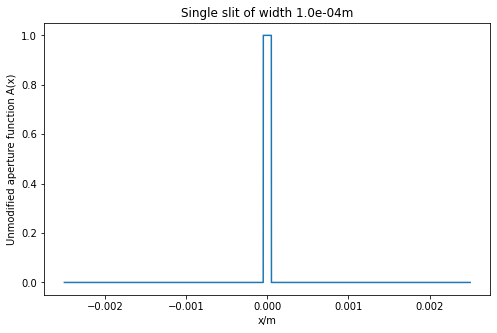

In [54]:
# Plot aperture function
plt.figure(figsize=(8,5))
single1.plot()

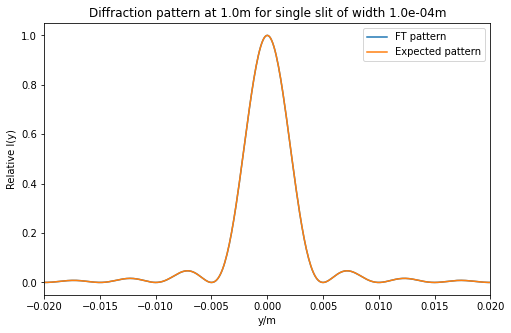

In [55]:
# Plotting the FT diffraction pattern and the expected pattern
plt.figure(figsize=(8,5))
plt.plot(y1, I1, label="FT pattern")
plt.plot(y1, I1_ex, label="Expected pattern")
plt.xlim(-0.02, 0.02)
plt.xlabel("y/m")
plt.ylabel("Relative I(y)")
plt.title(f"Diffraction pattern at 1.0m for "+single1.name)
plt.legend();

## <b>Core task 2</b>: Sinusoidal phase grating

In [56]:
class sin_grating(single_slit):
    def __init__(self, L, N, d, s, m):
        super().__init__(L, N, d)

        # Modifying aperture to add sinusoidal phase
        grating = (abs(self.x) < self.d/2)
        self.A[grating] = np.exp(1j * (m/2) * np.sin(2*np.pi*self.x[grating]/s))

        # Name for title of plots
        self.name = f"sinusoidal phase grating of width {self.d:.1e}m"

In [57]:
# Create aperture and calculate diffracted intensities
sinusoidal2 = sin_grating(L=50*2e-3, N=2**15, d=2e-3, s=100e-6, m=8)
y2, I2 = sinusoidal2.diffracted("far", distance=10.0)

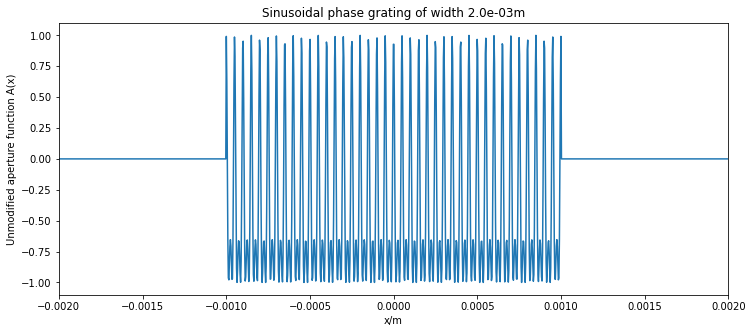

In [58]:
# Plot real part of unmodified aperture function
plt.figure(figsize=(12,5))
sinusoidal2.plot(0.002)

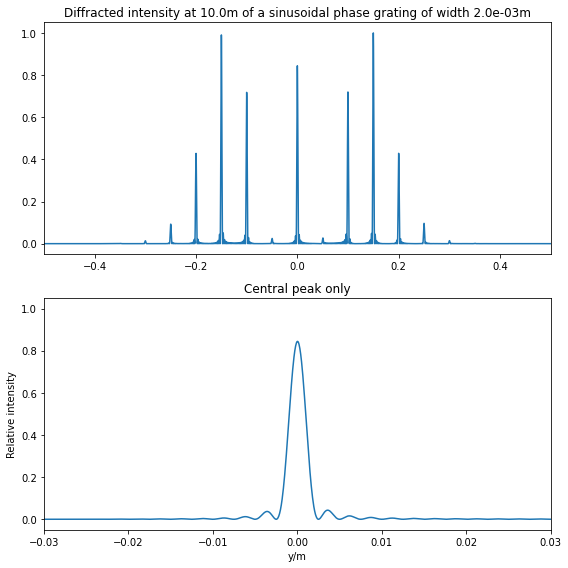

In [59]:
# Plot diffracted intensity
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(8,8))
ax1.plot(y2, I2)
ax2.plot(y2, I2)
ax1.set_xlim(-0.5, 0.5)
ax2.set_xlim(-0.03, 0.03)
plt.xlabel("y/m")
plt.ylabel("Relative intensity")
ax1.set_title("Diffracted intensity at 10.0m of a " + sinusoidal2.name)
ax2.set_title("Central peak only")
plt.tight_layout();

Multiplication by the phase function in the aperture results in convolution of the diffraction patterns of the top-hat and the phase function. 
<br>
<br>
The FT of the phase function is a series of modulated delta functions (approximated below by setting L=d i.e. a very long grating with no obstructions), so its convolution with the transforms of the top-hat (sinc) does indeed give the intensities shown above.

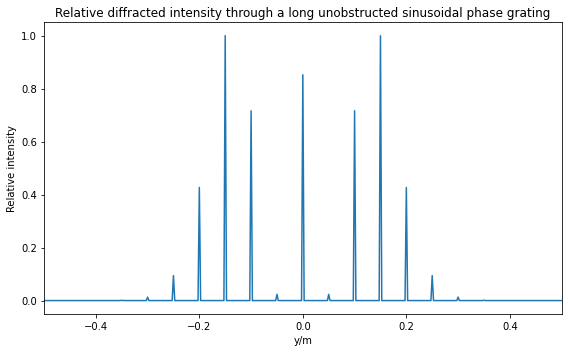

In [60]:
# Long unobstructed grating; set width of slit to be the same as the sampling window to make 
# unobstructed grating
sinusoidal2a = sin_grating(L=2e-3, N=2**15, d=2e-3, s=100e-6, m=8)
y2a, I2a = sinusoidal2a.diffracted("far", distance=10)

plt.figure(figsize=(8,5))
plt.plot(y2a, I2a)
plt.xlim(-0.5, 0.5)
plt.xlabel("y/m")
plt.ylabel("Relative intensity")
plt.title(f"Relative diffracted intensity through a long unobstructed sinusoidal phase grating")
plt.tight_layout();

## <b>Core task 3</b>: Near field

### a) Single clear slit

In [61]:
# Calculate intensity
d_ = 100e-6
L_ = 50*d_
N_ = 2**14
D_ = 5e-3
single3 = single_slit(L=L_, N=N_, d=d_)
y3a, I3a = single3.diffracted("near", distance=D_)

# Far field/unmodified A(x) intensity
psi3_far = np.sinc((k*d_*y3a/(2*D_))/np.pi)
I3_far = abs(psi3_far)**2

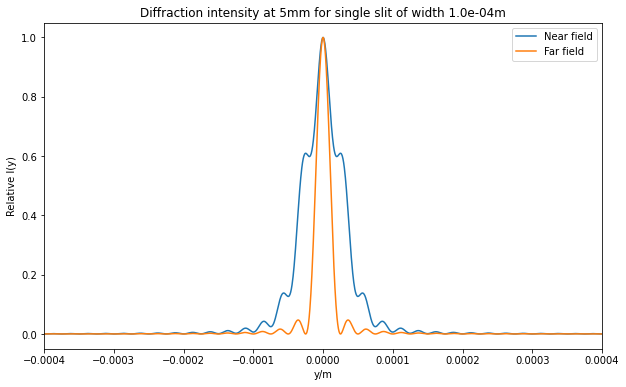

In [62]:
# Plotting the near and far field patterns
plt.figure(figsize=(10,6))
plt.plot(y3a, I3a, label="Near field")
plt.plot(y3a, I3_far, label="Far field")
plt.xlim(-4e-4,4e-4)
plt.xlabel("y/m")
plt.ylabel("Relative I(y)")  
plt.title("Diffraction intensity at 5mm for " + single3.name)
plt.legend();

Looks sensible, generic near field single-slit diffraction pattern

### b) Sinusoidal phase grating

In [63]:
sinusoidal3 = sin_grating(L=50*2e-3, N=2**17, d=2e-3, s=100e-6, m=8)
y3b, I3b = sinusoidal3.diffracted("near", distance=0.5)

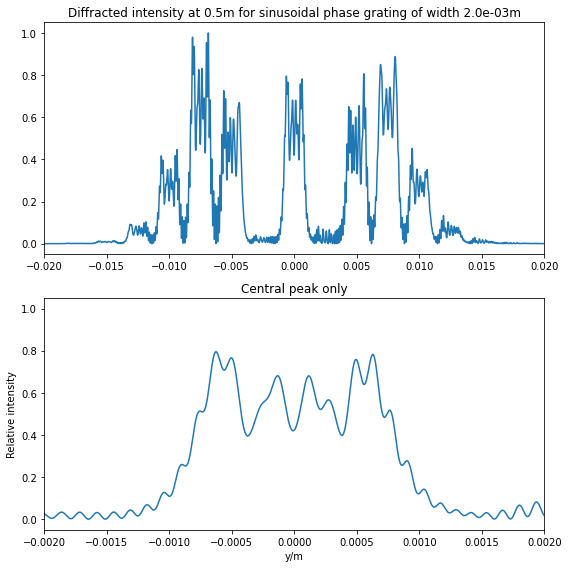

In [64]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(8,8))
ax1.plot(y3b, I3b)
ax2.plot(y3b, I3b)
ax1.set_xlim(-0.02, 0.02)
ax2.set_xlim(-0.002, 0.002)
plt.xlabel("y/m")
plt.ylabel("Relative intensity")
ax1.set_title("Diffracted intensity at 0.5m for " + sinusoidal3.name)
ax2.set_title("Central peak only")
plt.tight_layout();

Looks very interesting, seems perhaps to be some convolution of the single-slit near field pattern and some delta functions - difficult to determine from the many terms in the integral. Very cool though!

## <b>Supplementary task</b>: Multiple slits

### a) Double slit

In [65]:
class two_slit(aperture):
    def __init__(self, L, N, d, a):
        super().__init__(L, N)
        self.d = d
        self.a = a

        # Define unmodified aperture function (far field)
        self.A[abs(self.x-a/2) < d/2] = 1.0
        self.A[abs(self.x+a/2) < d/2] = 1.0

        # Name for title of plots
        self.name = f"double slit of width {self.d:.1e}m, spacing {self.a:.1e}m"

class three_slit(aperture):
    def __init__(self, L, N, d, a):
        super().__init__(L, N)
        self.d = d
        self.a = a

        # Define unmodified aperture function (far field)
        self.A[abs(self.x) < d/2] = 1.0
        self.A[abs(self.x-a) < d/2] = 1.0
        self.A[abs(self.x+a) < d/2] = 1.0

        # Name for title of plots
        self.name = f"triple slit of width {self.d:.1e}m, spacing {self.a:.1e}m"

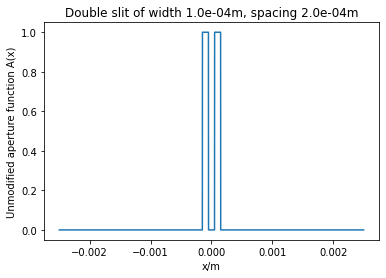

In [66]:
two = two_slit(L=50*100e-6, N=2**17, d=100e-6, a=200e-6)
y4a, I4a = two.diffracted("near", distance=5e-3) # D/(d^2/lmd) = 0.25, near field
two.plot()

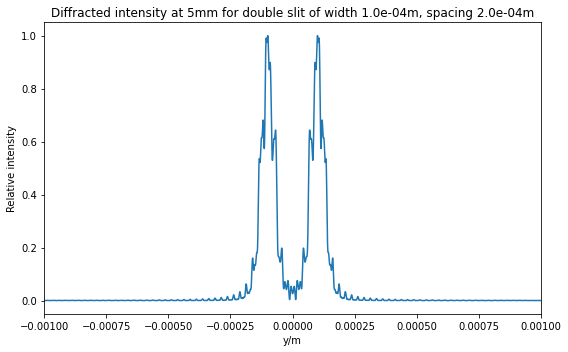

In [67]:
plt.figure(figsize=(8,5))
plt.plot(y4a, I4a)
plt.xlim(-1e-3, 1e-3)
plt.xlabel("y/m")
plt.ylabel("Relative intensity")
plt.title(f"Diffracted intensity at 5mm for " + two.name)
plt.tight_layout();

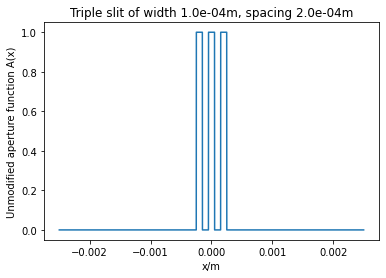

In [68]:
three = three_slit(L=50*100e-6, N=2**17, d=100e-6, a=200e-6)
y4b, I4b = three.diffracted("near", distance=5e-3) # D/(d^2/lmd) = 0.25, near field
three.plot()

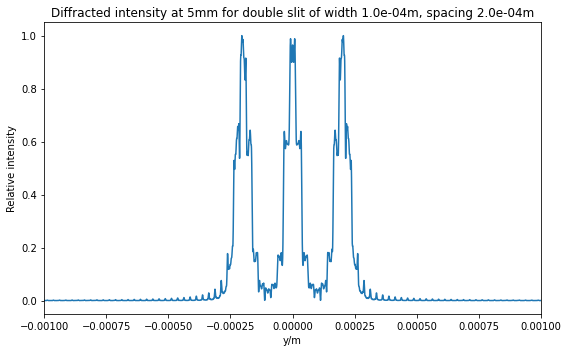

In [69]:
plt.figure(figsize=(8,5))
plt.plot(y4b, I4b)
plt.xlim(-1e-3, 1e-3)
plt.xlabel("y/m")
plt.ylabel("Relative intensity")
plt.title(f"Diffracted intensity at 5mm for " + two.name)
plt.tight_layout();